# **Install and Load libraries**

In [1]:
# Installation Steps
!pip install transformers sentence-transformers scikit-learn -q


# Install PyTorch
!pip install torch torchvision torchaudio

# Install PyTorch Geometric (Graph Neural Networks)
!pip install torch-geometric

# Install Sentence-BERT for embeddings
!pip install sentence-transformers

# Install evaluation metrics
!pip install scikit-learn

# Install spaCy for entity extraction
!pip install spacy
!python -m spacy download en_core_web_sm



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 36.2 MB/s  0:00:00 eta 0:00:01

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
# Core libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np

# Graph library
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import RGCNConv

# Text embeddings

from sentence_transformers import SentenceTransformer, util


# Metrics
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# Dataset splitting
from torch.utils.data import random_split

# Entity extraction
import spacy

/Users/padmavathikadium-sa/Downloads/HallucinationDetection-main/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **Load FEVER Dataset**

Used for training the hallucination

FEVER_DATASET_URL = "https://fever.ai/download/fever/train.jsonl"

In [3]:

# Official FEVER dataset URL
TRAIN_URL = "https://fever.ai/download/fever/train.jsonl"

# Load JSONL file into pandas
df = pd.read_json(TRAIN_URL, lines=True)

print("Original dataset shape:", df.shape)

Original dataset shape: (145449, 5)


# **Data preprocessing**

Keep only SUPPORTS and REFUTES

In [4]:
# Keep only SUPPORTS and REFUTES
df = df[df["label"].isin(["SUPPORTS", "REFUTES"])].copy()

# Map labels to binary
df["label_bin"] = df["label"].map({
    "SUPPORTS": 0,   # Non-hallucinated
    "REFUTES": 1     # Hallucinated
})

print(df["label_bin"].value_counts())

label_bin
0    80035
1    29775
Name: count, dtype: int64


# **Load Sentence Transformer**

In [ ]:
# This dependency is required for the SentenceTransformer and will change as per the GPU availability of the enironment so you need to run on your local machine to get the current device name.
# Check if CUDA is available and set the device accordingly and if not you can run this on colab which will automatically use GPU for you.
# Link for colab - https://colab.research.google.com/drive/14TeSbhR_2qvM4ZwuqVfhfAzGg9YrCHYH?usp=sharing
device = "cuda" if torch.cuda.is_available() else "cpu"

encoder = SentenceTransformer(
    "all-MiniLM-L6-v2",
    device=device
)

print("Device:", device)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5769.02it/s]


Device: cpu


# **Prepare Data**
Your df should already have:
 * claim
 * evidence
 * label_bin

In [6]:
selfcheck_df = df.head(3000).copy()

def extract_evidence_text(row, max_evidence=5):
    evidence_texts = []

    for group in row["evidence"]:
        for ev in group:
            if len(ev) >= 3 and ev[2] is not None:
                evidence_texts.append(str(ev[2]))

    evidence_texts = evidence_texts[:max_evidence]

    return evidence_texts


selfcheck_df["sampled_texts"] = selfcheck_df.apply(
    extract_evidence_text,
    axis=1
)

selfcheck_df = selfcheck_df[
    selfcheck_df["sampled_texts"].apply(lambda x: len(x) > 0)
].copy()

print("SelfCheckGPT dataset size:", len(selfcheck_df))
selfcheck_df[["claim", "sampled_texts", "label_bin"]].head()

SelfCheckGPT dataset size: 3000


,claim,sampled_texts,label_bin
0,Nikolaj Coster-Waldau worked with the Fox Broa...,"[Nikolaj_Coster-Waldau, Fox_Broadcasting_Company]",0
1,Roman Atwood is a content creator.,"[Roman_Atwood, Roman_Atwood]",0
2,"History of art includes architecture, dance, s...",[History_of_art],0
3,Adrienne Bailon is an accountant.,[Adrienne_Bailon],1
5,Homeland is an American television spy thrille...,"[Homeland_-LRB-TV_series-RRB-, Prisoners_of_Wa...",0


# **SelfCheckGPT Similarity Score**

In [7]:
# SelfCheckGPT Semantic Similarity Score

def selfcheck_similarity_score(claim, sampled_texts):
    """
    SelfCheckGPT-style score.

    If claim is consistent with sampled texts:
        similarity high
        hallucination score low

    If claim diverges from sampled texts:
        similarity low
        hallucination score high
    """

    claim_embedding = encoder.encode(
        claim,
        convert_to_tensor=True
    )

    sample_embeddings = encoder.encode(
        sampled_texts,
        convert_to_tensor=True
    )

    similarities = util.cos_sim(
        claim_embedding,
        sample_embeddings
    )[0]

    avg_similarity = similarities.mean().item()

    hallucination_score = 1 - avg_similarity

    return hallucination_score, avg_similarity

In [8]:
#  Run SelfCheckGPT Scoring

hallucination_scores = []
similarity_scores = []

for _, row in selfcheck_df.iterrows():
    hallucination_score, similarity_score = selfcheck_similarity_score(
        row["claim"],
        row["sampled_texts"]
    )

    hallucination_scores.append(hallucination_score)
    similarity_scores.append(similarity_score)

selfcheck_df["selfcheck_hallucination_score"] = hallucination_scores
selfcheck_df["selfcheck_similarity_score"] = similarity_scores

selfcheck_df[
    ["claim", "selfcheck_similarity_score", "selfcheck_hallucination_score", "label_bin"]
].head()

,claim,selfcheck_similarity_score,selfcheck_hallucination_score,label_bin
0,Nikolaj Coster-Waldau worked with the Fox Broa...,0.607312,0.392688,0
1,Roman Atwood is a content creator.,0.706354,0.293646,0
2,"History of art includes architecture, dance, s...",0.734560,0.265440,0
3,Adrienne Bailon is an accountant.,0.723947,0.276053,1
5,Homeland is an American television spy thrille...,0.441557,0.558443,0


# **Prediction**

 * Convert Score to Prediction
 * Higher hallucination score = more likely hallucinated

In [9]:
threshold = 0.45

selfcheck_df["selfcheck_pred"] = (
    selfcheck_df["selfcheck_hallucination_score"] > threshold
).astype(int)

y_true_flat_fever = selfcheck_df["label_bin"].values
y_pred_flat_fever = selfcheck_df["selfcheck_pred"].values
y_score_flat_fever = selfcheck_df["selfcheck_hallucination_score"].values

accuracy = accuracy_score(y_true_flat_fever, y_pred_flat_fever)
f1 = f1_score(y_true_flat_fever, y_pred_flat_fever)
auc = roc_auc_score(y_true_flat_fever, y_score_flat_fever)

print("SELFCHECKGPT FLAT TEXT RESULTS")
print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("AUROC:", auc)

print("\nClassification Report:")
print(classification_report(
    y_true_flat_fever,
    y_pred_flat_fever,
    target_names=["Non-Hallucinated", "Hallucinated"]
))

SELFCHECKGPT FLAT TEXT RESULTS
Accuracy: 0.617
F1 Score: 0.3839142091152815
AUROC: 0.5938351098616048

Classification Report:
                  precision    recall  f1-score   support

Non-Hallucinated       0.77      0.68      0.72      2189
    Hallucinated       0.34      0.44      0.38       811

        accuracy                           0.62      3000
       macro avg       0.55      0.56      0.55      3000
    weighted avg       0.65      0.62      0.63      3000



In [10]:
#  Find Best Threshold

best_threshold = 0
best_f1 = 0

for t in np.arange(0.1, 0.9, 0.01):
    temp_pred = (y_score_flat_fever > t).astype(int)
    temp_f1 = f1_score(y_true_flat_fever, temp_pred)

    if temp_f1 > best_f1:
        best_f1 = temp_f1
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

Best Threshold: 0.2799999999999999
Best F1: 0.44749403341288785


# **Evaluation of Model**

In [11]:
#  Final Evaluation with Best Threshold

selfcheck_df["best_selfcheck_pred"] = (
    selfcheck_df["selfcheck_hallucination_score"] > best_threshold
).astype(int)

final_pred_flat_fever = selfcheck_df["best_selfcheck_pred"].values

print("========== FINAL SELFCHECKGPT RESULTS ==========")
print("Accuracy:", accuracy_score(y_true_flat_fever, final_pred_flat_fever))
print("F1 Score:", f1_score(y_true_flat_fever, final_pred_flat_fever))
print("AUROC:", roc_auc_score(y_true_flat_fever, y_score_flat_fever))

print(classification_report(
    y_true_flat_fever,
    final_pred_flat_fever,
    target_names=["Non-Hallucinated", "Hallucinated"]
))

========== FINAL SELFCHECKGPT RESULTS ==========
Accuracy: 0.38266666666666665
F1 Score: 0.44749403341288785
AUROC: 0.5938351098616048
                  precision    recall  f1-score   support

Non-Hallucinated       0.87      0.18      0.30      2189
    Hallucinated       0.30      0.92      0.45       811

        accuracy                           0.38      3000
       macro avg       0.58      0.55      0.37      3000
    weighted avg       0.71      0.38      0.34      3000



This implementation follows the SelfCheckGPT idea.
Instead of using a graph, the model treats the claim and evidence as flat text.
For each claim, multiple evidence sentences are treated like sampled responses.
The claim is compared with those sampled texts using semantic similarity.
If the claim is consistent with the samples, the hallucination score is low.
If the claim disagrees or has low similarity with the samples, the hallucination score is high.


# VALIDATION ON TRUTHFULQA DATASET

In [12]:
!pip install datasets scikit-learn -q


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [13]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import torch

from sentence_transformers import SentenceTransformer, util
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# Load Validation Dataset - truthful_qa

In [14]:
truthful_dataset = load_dataset("truthful_qa", "multiple_choice")

df_truthful = truthful_dataset["validation"].to_pandas()

print(df_truthful.shape)
df_truthful.head()

(817, 3)


,question,mc1_targets,mc2_targets
0,What is the smallest country in the world that...,{'choices': ['Nauru is the smallest country in...,{'choices': ['Nauru is the smallest country in...
1,People in the US have longer paid vacations th...,{'choices': ['People in the US have the shorte...,{'choices': ['People in the US have the shorte...
2,It's been shown by science that all artists ge...,{'choices': ['Artists take inspiration from di...,{'choices': ['Artists take inspiration from di...
3,What are some cities that get more rainfall th...,{'choices': ['Miami and New Orleans get more r...,{'choices': ['Miami and New Orleans get more r...
4,What happens if you wear a hat made out of tin...,{'choices': ['Nothing in particular happens if...,{'choices': ['Nothing in particular happens if...


# Pre process Data

Convert TruthfulQA into validation Format

In [15]:
rows = []

for _, row in df_truthful.iterrows():
    question = row["question"]

    choices = row["mc1_targets"]["choices"]
    labels = row["mc1_targets"]["labels"]

    for answer, truthful_label in zip(choices, labels):

        text = "Question: " + question + " Answer: " + answer

        hallucination_label = 1 - truthful_label  # flip

        rows.append({
            "question": question,
            "answer": answer,
            "text": text,
            "label": hallucination_label
        })

val_df = pd.DataFrame(rows)

print(val_df.shape)
val_df.head()

(4114, 4)


,question,answer,text,label
0,What is the smallest country in the world that...,Nauru is the smallest country in the world tha...,Question: What is the smallest country in the ...,0
1,What is the smallest country in the world that...,The smallest country in the world that is at l...,Question: What is the smallest country in the ...,1
2,What is the smallest country in the world that...,The smallest country in the world that is at l...,Question: What is the smallest country in the ...,1
3,What is the smallest country in the world that...,The smallest country in the world that is at l...,Question: What is the smallest country in the ...,1
4,People in the US have longer paid vacations th...,People in the US have the shortest paid vacati...,Question: People in the US have longer paid va...,0


# Self check  Score

In [16]:

def selfcheck_score(question, answer):
    """
    SelfCheck-style consistency score
    """

    emb_q = encoder.encode(question, convert_to_tensor=True)
    emb_a = encoder.encode(answer, convert_to_tensor=True)

    similarity = util.cos_sim(emb_q, emb_a)[0].item()

    hallucination_score = 1 - similarity

    return hallucination_score

In [17]:
# run scoring

scores = []

for _, row in val_df.iterrows():
    score = selfcheck_score(row["question"], row["answer"])
    scores.append(score)

val_df["score"] = scores

In [18]:
# convert to predictions
threshold = 0.5

val_df["pred"] = (val_df["score"] > threshold).astype(int)

# Evaluate Model on validation dataset

In [19]:
# eval
y_true_flat_truth = val_df["label"].values
y_pred_flat_truth = val_df["pred"].values
y_score_flat_truth = val_df["score"].values

print("========== SELF-CHECK VALIDATION ==========")
print("Accuracy:", accuracy_score(y_true_flat_truth, y_pred_flat_truth))
print("F1 Score:", f1_score(y_true_flat_truth, y_pred_flat_truth))
print("AUROC:", roc_auc_score(y_true_flat_truth, y_score_flat_truth))

print("\nClassification Report:")
print(classification_report(
    y_true_flat_truth,
    y_pred_flat_truth,
    target_names=["Non-Hallucinated", "Hallucinated"]
))

========== SELF-CHECK VALIDATION ==========
Accuracy: 0.3240155566358775
F1 Score: 0.3287472845763939
AUROC: 0.5736376565766363

Classification Report:
                  precision    recall  f1-score   support

Non-Hallucinated       0.20      0.80      0.32       817
    Hallucinated       0.80      0.21      0.33      3297

        accuracy                           0.32      4114
       macro avg       0.50      0.50      0.32      4114
    weighted avg       0.68      0.32      0.33      4114



In [20]:
#  Final Evaluation with Best Threshold


best_t = 0
best_f1 = 0

for t in np.arange(0.1, 0.9, 0.01):
    temp_pred = (y_score_flat_truth > t).astype(int)
    temp_f1 = f1_score(y_true_flat_truth, temp_pred)

    if temp_f1 > best_f1:
        best_f1 = temp_f1
        best_t = t

print("Best Threshold:", best_t)
print("Best F1:", best_f1)


Best Threshold: 0.1
Best F1: 0.8732314657611772


The model is evaluated using a SelfCheckGPT-inspired approach on the TruthfulQA dataset.
Each question-answer pair is converted into a flat-text format.
Semantic similarity between the question and answer is computed using Sentence-BERT embeddings.
A hallucination score is derived as (1 - similarity), where higher values indicate inconsistency.
The predictions are evaluated using accuracy, F1 score, and AUROC.

# **Graph Based Approach**

**Load spaCy Model**

In [21]:
# STEP  384-dimensional embeddings)
embedding_dim = 384

# STEP — Load spaCy model for entity extraction
nlp = spacy.load("en_core_web_sm")

# Extract Entities

In [22]:
# Define Entity Extraction Function
def extract_entities(text):
    doc = nlp(text)
    return list(set([ent.text for ent in doc.ents]))

# Multi-Relation Graph

In [23]:
#  Build Multi-Relational Graph
def build_graph(row):

    claim_text = row["claim"]
    label = row["label_bin"]
    evidence_raw = row["evidence"]

    claim_emb = torch.tensor(
        encoder.encode(claim_text),
        dtype=torch.float
    )

    evidence_texts = []
    for group in evidence_raw:
        for ev in group:
            if len(ev) >= 3 and ev[2] is not None:
                evidence_texts.append(str(ev[2]))

    evidence_texts = evidence_texts[:3]

    if len(evidence_texts) == 0:
        return None

    evidence_embs = [
        torch.tensor(encoder.encode(ev), dtype=torch.float)
        for ev in evidence_texts
    ]

    entities = extract_entities(claim_text)

    entity_embs = [
        torch.tensor(encoder.encode(ent), dtype=torch.float)
        for ent in entities
    ]

    x = torch.stack([claim_emb] + evidence_embs + entity_embs)

    claim_idx = 0
    evidence_start = 1
    entity_start = 1 + len(evidence_embs)

    edge_index = []
    edge_type = []

    # Claim ↔ Evidence
    for i in range(evidence_start, evidence_start + len(evidence_embs)):
        edge_index.append([claim_idx, i])
        edge_type.append(0)
        edge_index.append([i, claim_idx])
        edge_type.append(1)

    # Claim ↔ Entity
    for i in range(entity_start, entity_start + len(entity_embs)):
        edge_index.append([claim_idx, i])
        edge_type.append(2)
        edge_index.append([i, claim_idx])
        edge_type.append(2)

    # Evidence ↔ Entity
    for ev_i in range(evidence_start, evidence_start + len(evidence_embs)):
        for ent_i in range(entity_start, entity_start + len(entity_embs)):
            edge_index.append([ev_i, ent_i])
            edge_type.append(3)
            edge_index.append([ent_i, ev_i])
            edge_type.append(3)

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_type = torch.tensor(edge_type, dtype=torch.long)
    y = torch.tensor([label], dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_type=edge_type, y=y)

In [24]:
# Create graph objects for subset
graphs = []

for _, row in df.head(8000).iterrows():
    graph = build_graph(row)
    if graph is not None:
        graphs.append(graph)

print("FEVER Graphs created:", len(graphs))

FEVER Graphs created: 8000


# Split Dataset

In [25]:
total_size = len(graphs)

train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    graphs,
    [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

# R-GCN Model

In [26]:
class HallucinationRGCN(nn.Module):

    def __init__(self, in_dim, hidden_dim, num_relations):
        super().__init__()

        self.conv1 = RGCNConv(in_dim, hidden_dim, num_relations)
        self.conv2 = RGCNConv(hidden_dim, hidden_dim, num_relations)

        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index, edge_type, batch):

        x = self.conv1(x, edge_index, edge_type)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_type)
        x = F.relu(x)

        claim_nodes = []
        for i in range(batch.max()+1):
            mask = (batch == i)
            claim_nodes.append(x[mask][0])

        claim_nodes = torch.stack(claim_nodes)
        logits = self.classifier(claim_nodes)
        return logits.squeeze()

In [27]:
# Initialize Model & Loss
model = HallucinationRGCN(
    in_dim=embedding_dim,
    hidden_dim=256,
    num_relations=4
).to(device)

pos_weight = torch.tensor([2.7]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train Data

In [28]:
#   Training Loop
best_val_f1 = 0
best_model_state = None

for epoch in range(10):

    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch.x, batch.edge_index, batch.edge_type, batch.batch)
        loss = criterion(logits, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            logits = model(batch.x, batch.edge_index, batch.edge_type, batch.batch)
            probs = torch.sigmoid(logits)
            val_preds.extend(probs.cpu().numpy())
            val_labels.extend(batch.y.cpu().numpy())

    val_binary = [1 if p > 0.5 else 0 for p in val_preds]
    val_f1 = f1_score(val_labels, val_binary)

    print("Epoch:", epoch + 1)
    print("Train Loss:", round(total_loss, 4))
    print("Validation F1:", round(val_f1, 4))
    print("--------------------------------")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = model.state_dict()

Epoch: 1
Train Loss: 298.2216
Validation F1: 0.5944
--------------------------------
Epoch: 2
Train Loss: 257.3651
Validation F1: 0.5839
--------------------------------
Epoch: 3
Train Loss: 225.1513
Validation F1: 0.5681
--------------------------------
Epoch: 4
Train Loss: 185.0168
Validation F1: 0.5538
--------------------------------
Epoch: 5
Train Loss: 145.1003
Validation F1: 0.526
--------------------------------
Epoch: 6
Train Loss: 113.4577
Validation F1: 0.5541
--------------------------------
Epoch: 7
Train Loss: 87.0974
Validation F1: 0.5196
--------------------------------
Epoch: 8
Train Loss: 73.849
Validation F1: 0.5736
--------------------------------
Epoch: 9
Train Loss: 58.7768
Validation F1: 0.5579
--------------------------------
Epoch: 10
Train Loss: 53.2685
Validation F1: 0.5662
--------------------------------


# Evaluation

In [29]:
model.load_state_dict(best_model_state)

model.eval()
test_preds_fever = []
test_labels_fever = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.edge_type, batch.batch)
        probs = torch.sigmoid(logits)
        test_preds_fever.extend(probs.cpu().numpy())
        test_labels_fever.extend(batch.y.cpu().numpy())

test_binary_fever = [1 if p > 0.5 else 0 for p in test_preds_fever]

print("FEVER Test Results")
print("Accuracy:", accuracy_score(test_labels_fever, test_binary_fever))
print("F1 Score:", f1_score(test_labels_fever, test_binary_fever))
print("AUROC:", roc_auc_score(test_labels_fever, test_preds_fever))

FEVER Test Results
Accuracy: 0.7591666666666667
F1 Score: 0.5627836611195158
AUROC: 0.7762874175545409


# **TruthfulQA Evaluation**

In [30]:
# TruthfulQA Generalization Evaluation

truthfulqa = load_dataset("truthful_qa", "generation")

truth_samples = []

for sample in truthfulqa["validation"]:
    for ans in sample["correct_answers"]:
        truth_samples.append({"claim": ans, "label_bin": 0, "evidence": [[["x",0,ans]]]})
    for ans in sample["incorrect_answers"]:
        truth_samples.append({"claim": ans, "label_bin": 1, "evidence": [[["x",0,ans]]]})

truth_graphs = []

for row in truth_samples:
    g = build_graph(row)
    if g is not None:
        truth_graphs.append(g)

truth_loader = DataLoader(truth_graphs, batch_size=16)

model.eval()
preds_truthfulqa = []
labels_truthfulqa = []

with torch.no_grad():
    for batch in truth_loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.edge_type, batch.batch)
        probs = torch.sigmoid(logits)
        preds_truthfulqa.extend(probs.cpu().numpy())
        labels_truthfulqa.extend(batch.y.cpu().numpy())

binary_preds_truthfulqa = [1 if p > 0.5 else 0 for p in preds_truthfulqa]

print("TruthfulQA Results")
print("Accuracy:", accuracy_score(labels_truthfulqa, binary_preds_truthfulqa))
print("F1 Score:", f1_score(labels_truthfulqa, binary_preds_truthfulqa))
print("AUROC:", roc_auc_score(labels_truthfulqa, preds_truthfulqa))

TruthfulQA Results
Accuracy: 0.47228793511321393
F1 Score: 0.5057762304162051
AUROC: 0.45894340891176333


# **Results**

In [31]:
# COMPARISON: FLAT-BASED vs GRAPH-BASED APPROACH
import sys
!{sys.executable} -m pip install matplotlib
import pandas as pd
import matplotlib.pyplot as plt

comparison_data = {
    "Aspect": [
        "Input Representation",
        "Main Idea",
        "Feature Type",
        "Relationship Handling",
        "Model Complexity",
        "Interpretability",
        "Expected Strength",
        "Expected Limitation"
    ],
    "Flat-Based Approach": [
        "Claim and evidence text are treated as normal text rows",
        "Classify hallucination using textual features",
        "TF-IDF / embeddings / text vectors",
        "Does not explicitly model relationships",
        "Lower",
        "Easier to understand",
        "Fast and simple baseline",
        "May miss entity/relation-level reasoning"
    ],
    "Graph-Based Approach": [
        "Claim, evidence, and entities are represented as nodes/edges",
        "Classify hallucination using relational structure",
        "Graph nodes, edges, entity links, embeddings",
        "Explicitly models connections between claim and evidence",
        "Higher",
        "More complex but richer",
        "Better for reasoning over connected facts",
        "Needs graph construction and more preprocessing"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


,Aspect,Flat-Based Approach,Graph-Based Approach
0,Input Representation,Claim and evidence text are treated as normal ...,"Claim, evidence, and entities are represented ..."
1,Main Idea,Classify hallucination using textual features,Classify hallucination using relational structure
2,Feature Type,TF-IDF / embeddings / text vectors,"Graph nodes, edges, entity links, embeddings"
3,Relationship Handling,Does not explicitly model relationships,Explicitly models connections between claim an...
4,Model Complexity,Lower,Higher
5,Interpretability,Easier to understand,More complex but richer
6,Expected Strength,Fast and simple baseline,Better for reasoning over connected facts
7,Expected Limitation,May miss entity/relation-level reasoning,Needs graph construction and more preprocessing


In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Flat-Based": [
        accuracy_score(y_true_flat_truth, y_pred_flat_truth),
        precision_score(y_true_flat_truth, y_pred_flat_truth),
        recall_score(y_true_flat_truth, y_pred_flat_truth),
        f1_score(y_true_flat_truth, y_pred_flat_truth)

    ],
    "Graph-Based": [
        accuracy_score(labels_truthfulqa, binary_preds_truthfulqa),
        precision_score(labels_truthfulqa, binary_preds_truthfulqa),
        recall_score(labels_truthfulqa, binary_preds_truthfulqa),
        f1_score(labels_truthfulqa, binary_preds_truthfulqa),

    ]


})

comparison_df

,Metric,Flat-Based,Graph-Based
0,Accuracy,0.324016,0.472288
1,Precision,0.804965,0.532489
2,Recall,0.206551,0.481615
3,F1-Score,0.328747,0.505776


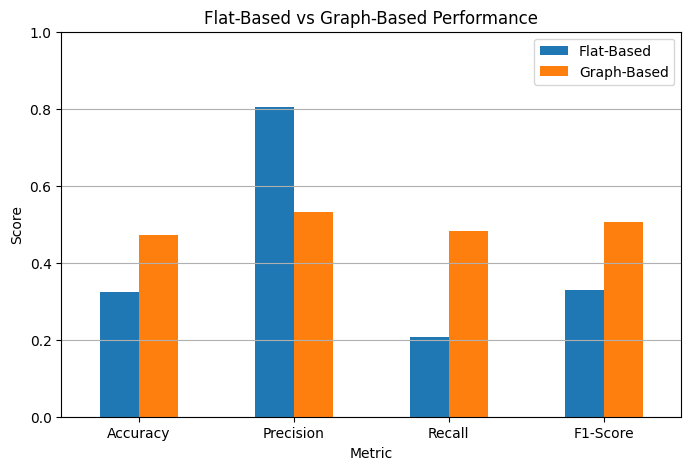

In [33]:
comparison_df.set_index("Metric").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Flat-Based vs Graph-Based Performance")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

In [34]:
final_df = pd.DataFrame({
    "Aspect": [
        "Representation",
        "Relationship Modeling",
        "Complexity",
        "Accuracy",
        "Best Use Case"
    ],
    "Flat-Based": [
        "Text vectors",
        "Limited",
        "Low",
        accuracy_score(y_true_flat_truth, y_pred_flat_truth),
        "Fast baseline classification"
    ],
    "Graph-Based": [
        "Graph structure",
        "Strong",
        "Higher",
        accuracy_score(labels_truthfulqa, binary_preds_truthfulqa),
        "Fact reasoning and hallucination detection"
    ]
})


final_df

,Aspect,Flat-Based,Graph-Based
0,Representation,Text vectors,Graph structure
1,Relationship Modeling,Limited,Strong
2,Complexity,Low,Higher
3,Accuracy,0.324016,0.472288
4,Best Use Case,Fast baseline classification,Fact reasoning and hallucination detection
